In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import re
from urllib.robotparser import RobotFileParser

**Phase - 1**

In [3]:
url = 'https://krisha.kz/prodazha/kvartiry/'
response = requests.get(url)
print(response.status_code)
soup = BeautifulSoup(response.text, 'html.parser')

200


In [4]:
l = []
seen_ids = set()

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (HTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
}

# robots.txt parser
rp = RobotFileParser()
rp.set_url("https://krisha.kz/robots.txt")
rp.read()


def can_fetch_url(url):
    try:
        return rp.can_fetch(headers["User-Agent"], url)
    except:
        return False


def get_html(url, retries=3):
    if not can_fetch_url(url):
        print(f'Blocked by robots.txt: {url}')
        return None

    for attempt in range(retries):
        try:
            response = requests.get(url, headers=headers, timeout=10)
            response.raise_for_status()
            return response.text
        except Exception as e:
            print(f'Error on {url}')
            print(e)
            time.sleep(2)
    return None


page = 1

while len(l) < 15000:
    url = f'https://krisha.kz/prodazha/kvartiry/?page={page}'
    print(f'Parsing page {page}')

    if not can_fetch_url(url):
        print(f'Skipped by robots.txt: {url}')
        page += 1
        continue

    html = get_html(url)

    if not html:
        print('Page skipped')
        page += 1
        continue

    soup = BeautifulSoup(html, 'html.parser')

    cards = soup.find_all(
        'div',
        class_="a-card a-storage-live ddl_product ddl_product_link not-colored is-visible"
    )

    if not cards:
        print('No cards found, stop')
        break

    for kv in cards:
        try:
            id_ = kv.get('data-id')

            if not id_ or id_ in seen_ids:
                continue

            seen_ids.add(id_)

            title_tag = kv.find('a', class_="a-card__title")
            price_tag = kv.find('div', class_="a-card__price")
            region_tag = kv.find('div', class_="a-card__subtitle")
            city_tag = kv.find('div', class_="a-card__stats-item")
            preview_tag = kv.find('div', class_="a-card__text-preview")

            title = title_tag.get_text(strip=True) if title_tag else None
            price = price_tag.get_text(strip=True) if price_tag else None
            region = region_tag.get_text(strip=True) if region_tag else None
            city = city_tag.get_text(strip=True) if city_tag else None
            preview_text = preview_tag.get_text(" ", strip=True) if preview_tag else ""

            rooms = None
            area_m2 = None
            floor = None
            total_floors = None

            if title:
                parts = [p.strip() for p in title.split('·')]

                if len(parts) > 0:
                    first_part = parts[0]
                    if '-комнат' in first_part:
                        rooms_text = first_part.split('-комнат')[0].strip()
                        if rooms_text.isdigit():
                            rooms = int(rooms_text)

                if len(parts) > 1:
                    area_text = parts[1].replace('м²', '').strip()
                    try:
                        area_m2 = float(area_text)
                    except:
                        area_m2 = None

                if len(parts) > 2:
                    floor_text = parts[2].replace('этаж', '').strip()
                    if '/' in floor_text:
                        floor_parts = floor_text.split('/')
                        if len(floor_parts) == 2:
                            current_floor = floor_parts[0].strip()
                            all_floors = floor_parts[1].strip()

                            if current_floor.isdigit():
                                floor = int(current_floor)
                            if all_floors.isdigit():
                                total_floors = int(all_floors)

            year = None
            all_text = f"{title or ''} {preview_text}"

            year_match = re.search(r'(\d{4})\s*г\.?\s*п\.?', all_text, re.IGNORECASE)
            if not year_match:
                year_match = re.search(r'(\d{4})\s*года?', all_text, re.IGNORECASE)
            if not year_match:
                year_match = re.search(r'(\d{4})', all_text)

            if year_match:
                y = int(year_match.group(1))
                if 1900 <= y <= 2030:
                    year = y

            l.append({
                'id': id_,
                'title': title,
                'price': price,
                'region': region,
                'city': city,
                'rooms': rooms,
                'area_m2': area_m2,
                'floor': floor,
                'total_floors': total_floors,
                'year': year
            })

            print(f'Total records: {len(l)}')

            if len(l) >= 15000:
                break

        except Exception as e:
            print('Error while parsing one card')
            print(e)

    page += 1
    time.sleep(random.uniform(0.3, 0.8))

df_raw = pd.DataFrame(l)

df_raw.to_csv('krisha_raw_data.csv', index=False, encoding='utf-8-sig')
df_raw.to_json('krisha_raw_data.json', orient='records', force_ascii=False)

print('Finished')
print(f'Total parsed: {len(df_raw)}')

Parsing page 1
Total records: 1
Total records: 2
Total records: 3
Total records: 4
Total records: 5
Total records: 6
Total records: 7
Total records: 8
Total records: 9
Total records: 10
Total records: 11
Total records: 12
Total records: 13
Total records: 14
Total records: 15
Total records: 16
Total records: 17
Total records: 18
Parsing page 2
Total records: 19
Total records: 20
Total records: 21
Total records: 22
Total records: 23
Total records: 24
Total records: 25
Total records: 26
Total records: 27
Total records: 28
Total records: 29
Total records: 30
Total records: 31
Total records: 32
Total records: 33
Total records: 34
Total records: 35
Total records: 36
Parsing page 3
Total records: 37
Total records: 38
Total records: 39
Total records: 40
Total records: 41
Total records: 42
Total records: 43
Total records: 44
Total records: 45
Total records: 46
Total records: 47
Total records: 48
Total records: 49
Total records: 50
Total records: 51
Total records: 52
Total records: 53
Parsing pa

**Phase - 2**

In [5]:
df = pd.DataFrame(l)
print(df.head())

           id                                        title        price  \
0   760568586   3-комнатная квартира · 72.9 м² · 5/12 этаж  29 500 000〒   
1   693327334     3-комнатная квартира · 85 м² · 1/10 этаж  48 500 000〒   
2  1011293513     3-комнатная квартира · 69 м² · 5/17 этаж  65 000 000〒   
3  1011607647  3-комнатная квартира · 66.3 м² · 10/12 этаж  69 500 000〒   
4  1008968314      1-комнатная квартира · 32 м² · 4/5 этаж  13 700 000〒   

                               region    city  rooms  area_m2  floor  \
0              Сарайшык р-н, А 108 34  Астана      3     72.9    5.0   
1                Алихан Бокейхан 15/1  Астана      3     85.0    1.0   
2  Есильский р-н, Хусейн Бен Талал 30  Астана      3     69.0    5.0   
3    Алмалинский р-н, ул. Толе би 274  Алматы      3     66.3   10.0   
4        Сарыарка р-н, Шакен Айманова  Астана      1     32.0    4.0   

   total_floors    year  
0          12.0  2023.0  
1          10.0  2022.0  
2          17.0  2025.0  
3          1

Handle missing values

In [6]:
print(df.isna().sum())

id                 0
title              0
price              0
region             0
city               0
rooms              0
area_m2            0
floor           1702
total_floors    1702
year               2
dtype: int64


In [7]:
df = df.dropna(subset=['floor', 'total_floors', 'year'])
print(df.isna().sum())

id              0
title           0
price           0
region          0
city            0
rooms           0
area_m2         0
floor           0
total_floors    0
year            0
dtype: int64


Remove duplicate rows

In [8]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

0


Standardize data types

In [9]:
print(df.dtypes)

id                  str
title               str
price               str
region              str
city                str
rooms             int64
area_m2         float64
floor           float64
total_floors    float64
year            float64
dtype: object


In [10]:
df.drop(columns = ['id'], inplace = True)

In [11]:
df['floor'] = df['floor'].astype(int)
df['total_floors'] = df['total_floors'].astype(int)
df['year'] = df['year'].astype(int)

In [12]:
df['price'] = pd.to_numeric(
    df['price']
    .str.replace('\xa0', '', regex=False)
    .str.replace('от ', '', regex=False)
    .str.replace('〒', '', regex=False)
    .str.strip(),
    errors='coerce'
)

In [13]:
print(df.dtypes)

title               str
price             int64
region              str
city                str
rooms             int64
area_m2         float64
floor             int64
total_floors      int64
year              int64
dtype: object


Detect and Handle Outliers

In [14]:
num_cols = ['price', 'area_m2', 'rooms', 'floor', 'total_floors', 'year']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]

    print(f"{col}: {len(outliers)} outliers")

price: 948 outliers
area_m2: 666 outliers
rooms: 188 outliers
floor: 515 outliers
total_floors: 121 outliers
year: 10 outliers


In [15]:
# prices up to 500_000_000 are realistic but more than it may be errors
df[df['price'] > 500_000_000]

,title,price,region,city,rooms,area_m2,floor,total_floors,year
7087,8-комнатная квартира · 700 м² · 2/2 этаж,1000000072,"Медеуский р-н, мкр Горный Гигант, Жамакаева 25...",Алматы,8,700.0,2,2,2006
7817,5-комнатная квартира · 320 м² · 10/10 этаж,550000000,"Медеуский р-н, Рубинштейна 21А",Алматы,5,320.0,10,10,2017
8209,7-комнатная квартира · 300 м² · 6/7 этаж,760000000,"Бостандыкский р-н, Мкр «Мирас» 31",Алматы,7,300.0,6,7,2016
9046,17-комнатная квартира · 866 м² · 20/21 этаж,932422200,"Есильский р-н, Мангилик Ел 62",Астана,17,866.0,20,21,2025
9259,2-комнатная квартира · 120 м² · 20/25 этаж,600000000,"Есильский р-н, Достык",Астана,2,120.0,20,25,2019


In [16]:
df = df[df['price'] <= 500_000_000]

In [17]:
print(df[['rooms', 'area_m2']].agg(['min', 'max', 'mean']))
# so outliers are just genuine extremes

         rooms     area_m2
min   1.000000    4.500000
max   8.000000  886.000000
mean  2.265819   65.958955


In [18]:
print(df[['floor', 'total_floors']].agg(['min', 'max', 'mean']))
# so here is the same, all are realistic

          floor  total_floors
min    1.000000      1.000000
max   30.000000     41.000000
mean   5.343089      8.930404


In [19]:
print(df['year'].agg(['min', 'max', 'mean']))
# as we have previously made the filter (1900, 2030), we need  to delete just 2027 values

min     1902.00000
max     2027.00000
mean    2007.50222
Name: year, dtype: float64


In [20]:
dfl = df[df['year'] == 2027]
print(len(dfl))

45


In [21]:
df = df[df['year'] <= 2026]

In [22]:
print(len(df))

13246


Feature Engineering

In [23]:
df['price_per_m2'] = df['price'] / df['area_m2']
df['floor_ratio'] = df['floor'] / df['total_floors']
df['apartment_age'] = 2026 - df['year']
df['price_category'] = pd.cut(
    df['price'],
    bins=[0, 15000000, 30000000, 60000000, float('inf')],
    labels=['budget', 'mid', 'high', 'luxury']
)
df['size_category'] = pd.cut(
    df['area_m2'],
    bins=[0, 40, 70, 100, float('inf')],
    labels=['small', 'medium', 'large', 'very_large']
)

Text Normalization

In [24]:
#extracting keywords
df['district'] = df['region'].str.extract(r'([А-Яа-яA-Za-z\- ]+р-н)')
df['district'] = df['district'].fillna('Unknown')
df['district'] = df['district'].astype('category')

In [25]:
#converting to lowercase
text_cols = ['region', 'city', 'district']

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

In [26]:
df['title'] = df['title'].str.replace(r'\s+', ' ', regex=True).str.strip()

Final cleaned dataset

In [27]:
df.to_csv('cleaned_data.csv', index=False, encoding='utf-8-sig')
df.to_json('cleaned_data.json', orient='records', force_ascii=False)

In [28]:
before_rows = len(df_raw)
after_rows = len(df)
df.drop_duplicates(inplace=True)
comparison = pd.DataFrame({
    'Metric': ['Number of rows', 'Missing values', 'Duplicates'],
    'Before Cleaning': [
        before_rows,
        df_raw.isnull().sum().sum(),
        df_raw.duplicated().sum()
    ],
    'After Cleaning': [
        after_rows,
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

print(comparison)

           Metric  Before Cleaning  After Cleaning
0  Number of rows            15000           13246
1  Missing values             3406               0
2      Duplicates                0               0


In [29]:
print(df.head(3))

                                        title     price  \
0  3-комнатная квартира · 72.9 м² · 5/12 этаж  29500000   
1    3-комнатная квартира · 85 м² · 1/10 этаж  48500000   
2    3-комнатная квартира · 69 м² · 5/17 этаж  65000000   

                               region    city  rooms  area_m2  floor  \
0              сарайшык р-н, а 108 34  астана      3     72.9      5   
1                алихан бокейхан 15/1  астана      3     85.0      1   
2  есильский р-н, хусейн бен талал 30  астана      3     69.0      5   

   total_floors  year   price_per_m2  floor_ratio  apartment_age  \
0            12  2023  404663.923182     0.416667              3   
1            10  2022  570588.235294     0.100000              4   
2            17  2025  942028.985507     0.294118              1   

  price_category size_category       district  
0            mid         large   сарайшык р-н  
1           high         large        unknown  
2         luxury        medium  есильский р-н  


Phase 3: Exploratory Data Analysis

descriptive statistics

In [30]:
print(df.describe())

              price         rooms       area_m2         floor  total_floors  \
count  1.321300e+04  13213.000000  13213.000000  13213.000000  13213.000000   
mean   4.028232e+07      2.266404     65.960507      5.341179      8.925225   
std    3.464516e+07      0.948023     34.929553      3.742466      4.619786   
min    1.200000e+06      1.000000      4.500000      1.000000      1.000000   
25%    2.180000e+07      2.000000     44.000000      3.000000      5.000000   
50%    3.150000e+07      2.000000     59.000000      4.000000      9.000000   
75%    4.680000e+07      3.000000     77.000000      7.000000     12.000000   
max    4.650000e+08      8.000000    886.000000     30.000000     41.000000   

               year  price_per_m2   floor_ratio  apartment_age  
count  13213.000000  1.321300e+04  13213.000000   13213.000000  
mean    2007.444789  5.927539e+05      0.613169      18.555211  
std       20.226935  2.738178e+05      0.281006      20.226935  
min     1902.000000  2.85714

distributions

Skewness: 4.02
Mean: 40282322 Median: 31499999
Standard deviation: 34645157


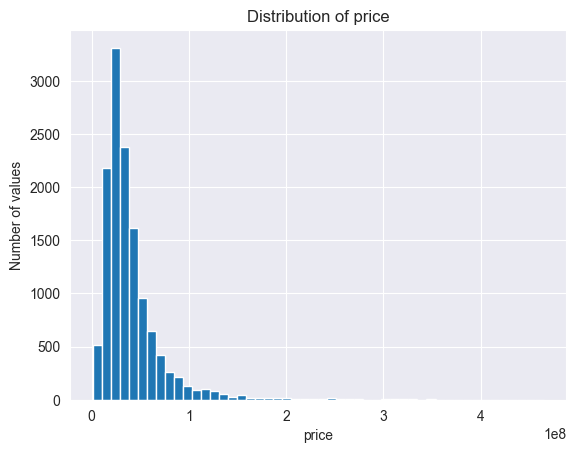

Skewness: -0.96
Mean: 2007 Median: 2018
Standard deviation: 20


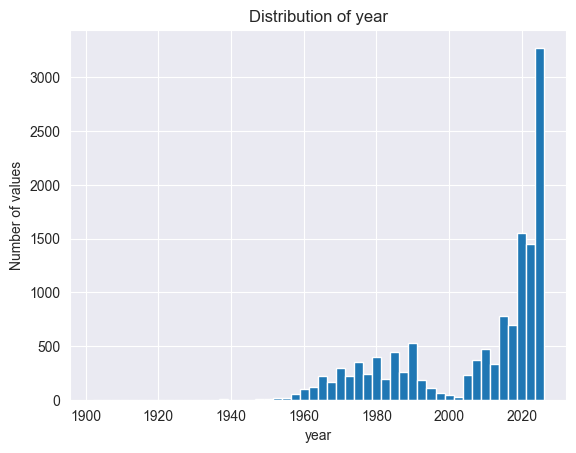

In [31]:
import matplotlib.pyplot as plt
key_variables = ['price', 'year']
for col in key_variables:
    print('Skewness:', round(df[col].skew(), 2))

    mean = round(df[col].mean())
    median = round(df[col].median())
    print('Mean:', mean, 'Median:', median)

    std = round(df[col].std())
    print('Standard deviation:',std)

    plt.figure()
    plt.hist(df[col], bins = 50)
    plt.title(f'Distribution of {col}')
    plt.ylabel('Number of values')
    plt.xlabel(col)
    plt.show()

Correlation analysis

In [32]:
numeric_df = df.select_dtypes(include = 'number')

print(numeric_df.corr())
# we can see that price and area are strongly positively correlated
# total floors and year are also moderately correlated

                  price     rooms   area_m2     floor  total_floors      year  \
price          1.000000  0.525215  0.723156  0.158969      0.232913  0.273545   
rooms          0.525215  1.000000  0.751802  0.003990     -0.003366 -0.062474   
area_m2        0.723156  0.751802  1.000000  0.095343      0.124845  0.168641   
floor          0.158969  0.003990  0.095343  1.000000      0.675366  0.330458   
total_floors   0.232913 -0.003366  0.124845  0.675366      1.000000  0.498937   
year           0.273545 -0.062474  0.168641  0.330458      0.498937  1.000000   
price_per_m2   0.662162  0.035934  0.123800  0.199762      0.316112  0.354055   
floor_ratio   -0.028009  0.011954 -0.001702  0.582454     -0.101294 -0.088517   
apartment_age -0.273545  0.062474 -0.168641 -0.330458     -0.498937 -1.000000   

               price_per_m2  floor_ratio  apartment_age  
price              0.662162    -0.028009      -0.273545  
rooms              0.035934     0.011954       0.062474  
area_m2        

Group-by analysis

In [33]:
# Districts with price mean and per_m2 mean
top_districts = (
    df.groupby('district')
    .agg({
        'price': 'mean',
        'price_per_m2': 'mean',
        'area_m2': 'mean'
    })
    .sort_values('price', ascending=False)
    .head(10)
)

pd.options.display.float_format = '{:.0f}'.format
top_districts = top_districts.round(0)
print(top_districts)
# we notice that 'медеуский' district is the top-1

                      price  price_per_m2  area_m2
district                                          
медеуский р-н     101228241       1022041       95
бостандыкский р-н  79289277        978250       79
есильский р-н      54150625        740686       72
алмалинский р-н    54013277        875729       62
ауэзовский р-н     45088825        773459       59
нура р-н           44330734        692661       64
наурызбайский р-н  41154621        671340       61
сарайшык р-н       40391606        620417       63
каратауский р-н    39543537        523571       74
алматы р-н         38923206        570368       67


In [34]:
# Comparing the new and old apartment prices
age_analysis = df.groupby('apartment_age').agg({
    'price': 'mean',
    'price_per_m2': 'mean'
}).reset_index()

age_analysis = age_analysis.sort_values('apartment_age')

print(age_analysis.head(10))
# generally, new apartments cost more expensive, but the trend is not directly linear, here are some anomalies

   apartment_age    price  price_per_m2
0              0 40849673        653743
1              1 43572174        715099
2              2 47459185        701674
3              3 48162903        703129
4              4 51469939        694408
5              5 48613500        667223
6              6 53226166        699452
7              7 48681449        657262
8              8 44923587        621482
9              9 43749949        607677


In [35]:
# Size VS Price
size_analysis = df.groupby('size_category').agg({
    'price': 'mean',
    'price_per_m2': 'mean',
    'area_m2': 'mean'
})

print(size_analysis.round(0))
# prices get higher as size increases, but the price for m2 is almost same for initial 3 categories

                 price  price_per_m2  area_m2
size_category                                
small         20936013        610927       34
medium        30410266        558268       55
large         49952183        598558       83
very_large    99943904        715110      139


TOP-N and BOTTOM-N

In [36]:
top_5_expensive = df.sort_values('price', ascending=False).head(7)
print(top_5_expensive[['price', 'area_m2', 'price_per_m2', 'district']])
# High total price is driven by a combination of size and location.

           price  area_m2  price_per_m2           district
7946   465000000      432       1075891      медеуский р-н
13014  456000000      224       2038444      медеуский р-н
13114  450000000      200       2250000  бостандыкский р-н
13890  420000000      280       1500000      медеуский р-н
8582   405469800      167       2430000  бостандыкский р-н
10274  400000000      347       1152406  бостандыкский р-н
13122  400000000      330       1212121      медеуский р-н


In [37]:
bottom_5_cheap = (
    df[df['district'] != 'unknown']
    .sort_values('price', ascending=True)
    .head(7)
)

print(bottom_5_cheap[['price', 'area_m2', 'price_per_m2', 'district']])

         price  area_m2  price_per_m2                 district
3113   4800000       14        342857           казыбек би р-н
3306   7000000       30        231023             сарыарка р-н
4951   7200000       44        162896           казыбек би р-н
246    7500000       16        460123               алматы р-н
14285  7600000       43        175926  алихана бокейханова р-н
11446  7800000       44        177273  алихана бокейханова р-н
3449   7900000       31        256494  алихана бокейханова р-н


Hypothesis

**Hypothesis 1**
H0: average price for m2 is same for all floor types
H1: middle floors more expensive

In [38]:
# Exploratory analysis (not a statistical test)
def floor_type(row):
    if row['floor'] == 1:
        return 'first_floor'
    elif row['floor'] == row['total_floors']:
        return 'last_floor'
    else:
        return 'middle_floor'

df['floor_type'] = df.apply(floor_type, axis=1)

floor_analysis = df.groupby('floor_type').agg({

    'price': 'mean',

    'price_per_m2': 'mean',

    'area_m2': 'mean'

}).round(0)

print(floor_analysis)

                price  price_per_m2  area_m2
floor_type                                  
first_floor  35413808        521416       64
last_floor   34719228        520008       64
middle_floor 42287684        620112       67


In [39]:
#Result:
#Middle floors have higher average price_per_m2 (~624k) compared to first and last floors (~539k).

#Conclusion:
#The hypothesis is confirmed. Floor position affects apartment pricing.

In [40]:
# Real test (t-test)

from scipy.stats import ttest_ind

middle = df[df['floor_type'] == 'middle_floor']['price_per_m2']
not_middle = df[df['floor_type'] != 'middle_floor']['price_per_m2']

t_stat, p_value = ttest_ind(middle, not_middle, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: middle floors are significantly more expensive")
else:
    print("Fail to reject H0")

T-stat: 18.347240174545547
P-value: 2.9776719839935276e-73
Reject H0: middle floors are significantly more expensive


**Hypothesis 2**
H0: There is no difference in average price per m² between luxury and non-luxury apartments.
H1: Luxury apartments have a higher average price per m².

In [41]:
# Initial analysis
luxury_threshold = df['price'].quantile(0.90)

df['is_luxury'] = df['price'] >= luxury_threshold

luxury_analysis = df.groupby('is_luxury').agg({
    'price': 'mean',
    'price_per_m2': 'mean',
    'area_m2': 'mean',
    'apartment_age': 'mean',
    'floor_ratio': 'mean'
}).round(0)

print("Luxury threshold:", luxury_threshold)

print(luxury_analysis)

Luxury threshold: 72000000.0
              price  price_per_m2  area_m2  apartment_age  floor_ratio
is_luxury                                                             
False      31621221        549188       59             20            1
True      117151208        979407      126              9            1


In [42]:
# Result:
# Luxury apartments have larger area (126 m2 vs 60 m2)
# and significantly higher price_per_m2 (979k vs 560k).

# Conclusion:
# The hypothesis is confirmed. Luxury apartments belong to a premium segment,
# where both size and price per m2 are higher.

In [43]:
# Real test

from scipy.stats import ttest_ind

luxury = df[df['is_luxury'] == True]['price_per_m2']
non_luxury = df[df['is_luxury'] == False]['price_per_m2']

t_stat, p_value = ttest_ind(luxury, non_luxury, equal_var=False)

print("T-test results:")
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0 → Luxury apartments have significantly higher price per m²")
else:
    print("Fail to reject H0")

T-test results:
T-statistic: 38.4822623885732
P-value: 9.90996524171043e-223
Reject H0 → Luxury apartments have significantly higher price per m²


In [44]:
luxury_districts = (
    df[df['is_luxury']]
    .groupby('district')
    .size()
    .sort_values(ascending=False)
    .head(3)
)

print(luxury_districts)

district
бостандыкский р-н    343
есильский р-н        228
медеуский р-н        160
dtype: int64


Hypothesis 3
H0: The average price per m² is the same across all districts.
H1: At least one district has a significantly different average price per m².

In [45]:
# ANOVA test
from scipy.stats import f_oneway

district_analysis = df.groupby('district')['price_per_m2'].mean().sort_values(ascending=False)

print("Exploratory analysis (mean price_per_m2 by district):")
print(district_analysis.head(10))

groups = [group['price_per_m2'].values for name, group in df.groupby('district')]

f_stat, p_value = f_oneway(*groups)

print("ANOVA results:")
print("F-statistic:", f_stat)
print("P-value:", p_value)

# --- Conclusion ---
if p_value < 0.05:
    print("Reject H0 → District significantly affects apartment prices")
else:
    print("Fail to reject H0")

Exploratory analysis (mean price_per_m2 by district):
district
медеуский р-н       1022041
бостандыкский р-н    978250
алмалинский р-н      875729
ауэзовский р-н       773459
есильский р-н        740686
нура р-н             692661
наурызбайский р-н    671340
турксибский р-н      646056
алатауский р-н       634188
жетысуский р-н       633522
Name: price_per_m2, dtype: float64
ANOVA results:
F-statistic: 564.8365934061798
P-value: 0.0
Reject H0 → District significantly affects apartment prices


In [46]:
# Additional interesting hypothesis
# Hypothesis 4: Same price category apartments have large variation in area

price_bins = pd.qcut(df['price'], q=10)

area_variation = df.groupby(price_bins)['area_m2'].agg(['mean', 'min', 'max']).round(0)

print(area_variation)

                           mean  min  max
price                                    
(1199999.999, 14500000.0]    41    4   90
(14500000.0, 19500000.0]     48   11  120
(19500000.0, 23500000.0]     50   21  250
(23500000.0, 27000000.0]     52   20  361
(27000000.0, 31499999.0]     55   27  130
(31499999.0, 36419800.0]     61   27  190
(36419800.0, 43000000.0]     67   23  188
(43000000.0, 52000000.0]     75   26  765
(52000000.0, 72000000.0]     86   39  300
(72000000.0, 465000000.0]   127   20  886


In [47]:
# Result:
# Within the same price bins, apartment sizes range from as low as 10 m2
# to over 600 m2.

# Conclusion:
# The hypothesis is confirmed. Price is not determined by size alone.
# This suggests market inefficiency and presence of overpriced and underpriced listings.

In [48]:
# Key Insight:
# The real estate market shows strong inefficiency:
# apartments with similar prices can differ drastically in size.
# This indicates that factors like location, building quality,
# and listing conditions significantly influence pricing.

Time-based analysis

In [49]:
# Price trend over years (graph 7)
year_analysis = df.groupby('year').agg({
    'price': 'mean',
    'price_per_m2': 'mean',
    'area_m2': 'mean'
}).round(0)

print(year_analysis.tail(10))


        price  price_per_m2  area_m2
year                                
2017 43749949        607677       69
2018 44923587        621482       70
2019 48681449        657262       74
2020 53226166        699452       73
2021 48613500        667223       71
2022 51469939        694408       72
2023 48162903        703129       69
2024 47459185        701674       67
2025 43572174        715099       61
2026 40849673        653743       60


In [50]:
# Caption: Price per m2 varies across building construction years,
# indicating how newer buildings tend to have higher market value

Phase 4: Visualizations

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

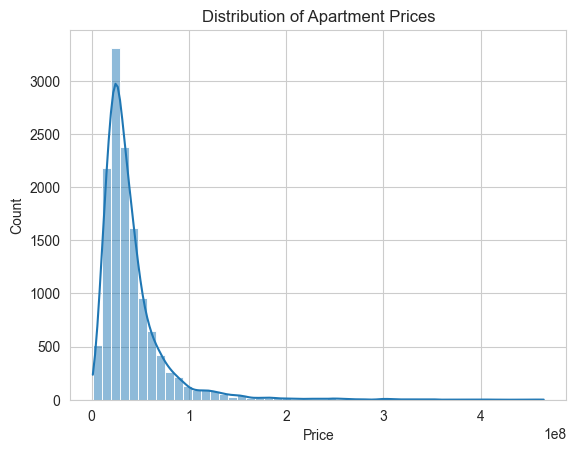

In [52]:
#1 Histogram
plt.figure()
sns.histplot(df['price'], bins=50, kde = True)
plt.title("Distribution of Apartment Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# Caption: Prices are right-skewed with most apartments in lower price ranges

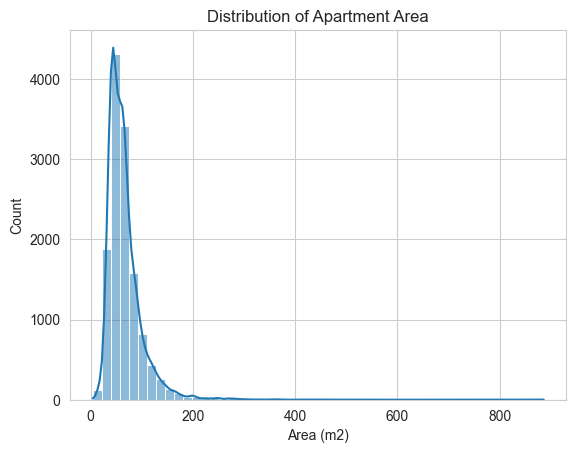

In [53]:
#2 Histogram
plt.figure()
sns.histplot(df['area_m2'], bins=50, kde = True)
plt.title("Distribution of Apartment Area")
plt.xlabel("Area (m2)")
plt.ylabel("Count")
plt.show()

# Caption: Most apartments fall within medium size range

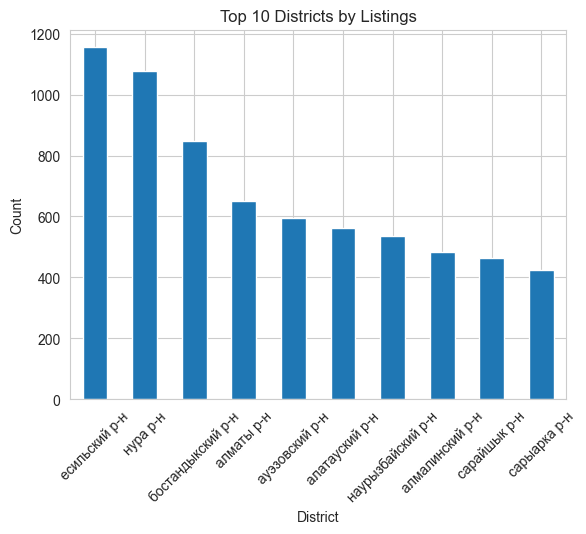

In [54]:
#3 Bar chart
df_filtered = df[df['district'] != 'unknown']

top_districts = df_filtered['district'].value_counts().head(10)

plt.figure()
top_districts.plot(kind='bar')
plt.title("Top 10 Districts by Listings")
plt.xlabel("District")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Caption: Some districts dominate the number of listings

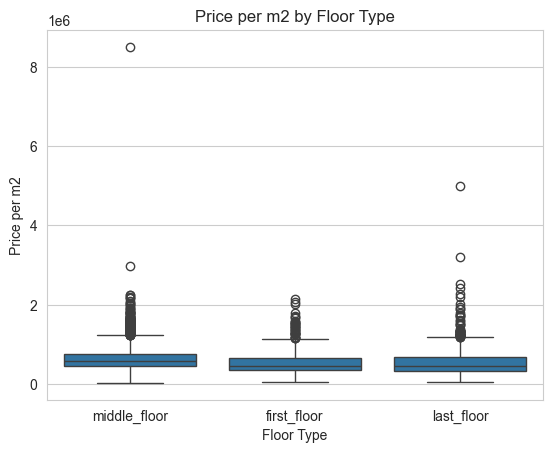

In [55]:
#4 Boxplot
plt.figure()
sns.boxplot(data=df, x='floor_type', y='price_per_m2')
plt.title("Price per m2 by Floor Type")
plt.xlabel("Floor Type")
plt.ylabel("Price per m2")
plt.show()

# Caption: Middle floors tend to have higher median prices

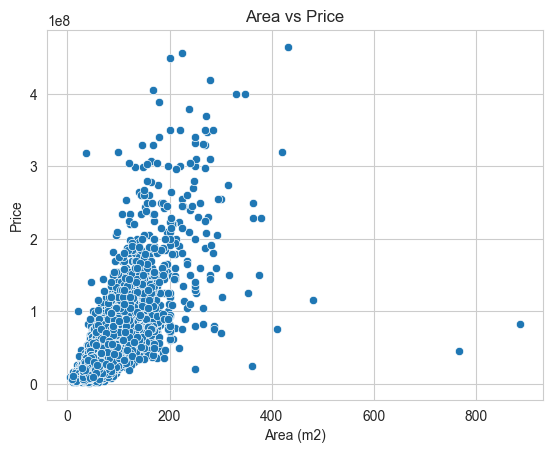

In [56]:
#5 Scatterplot
plt.figure()
sns.scatterplot(data=df, x='area_m2', y='price')
plt.title("Area vs Price")
plt.xlabel("Area (m2)")
plt.ylabel("Price")
plt.show()

# Caption: Larger apartments generally have higher prices

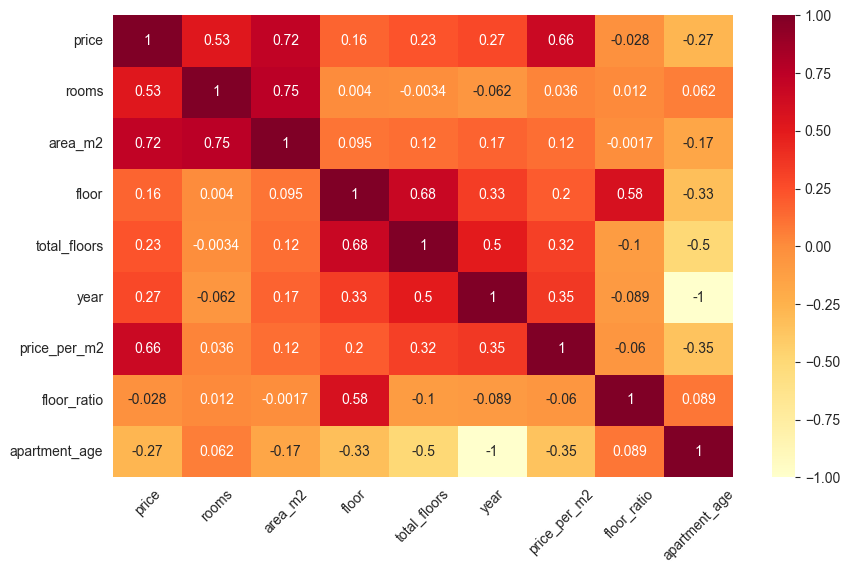

In [57]:
#6 Heatmap
numeric_df = df.select_dtypes(include = 'number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='YlOrRd')
plt.xticks(rotation=45)
plt.show()
# Caption: total floors and year are correlated moderately

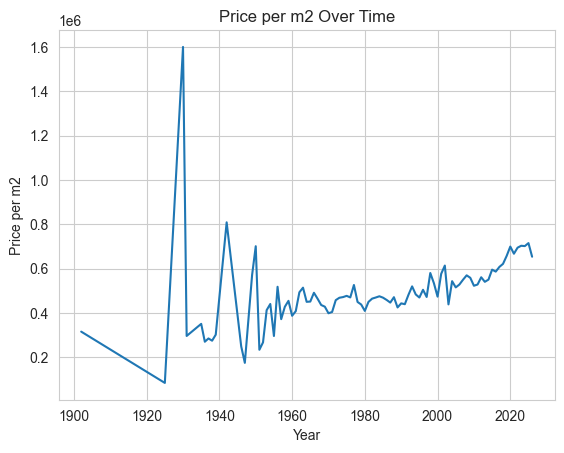

In [58]:
#7
year_analysis = df.groupby('year')['price_per_m2'].mean()

plt.figure()
plt.plot(year_analysis.index, year_analysis.values)
plt.title("Price per m2 Over Time")
plt.xlabel("Year")
plt.ylabel("Price per m2")
plt.show()

# Caption: Price per m2 shows a trend over time, indicating market changes

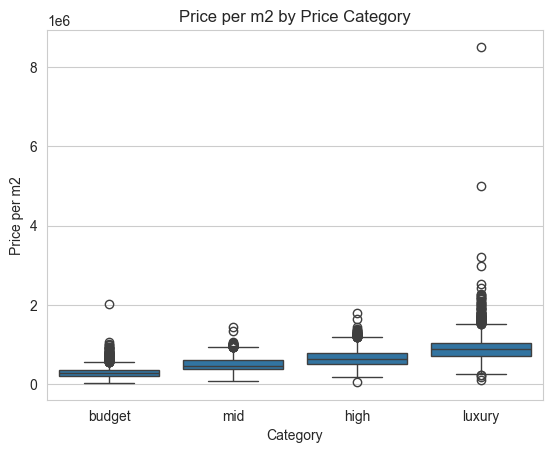

In [59]:
#8
plt.figure()
sns.boxplot(data=df, x='price_category', y='price_per_m2')
plt.title("Price per m2 by Price Category")
plt.xlabel("Category")
plt.ylabel("Price per m2")
plt.show()

# Caption: Higher price categories have higher price per m2

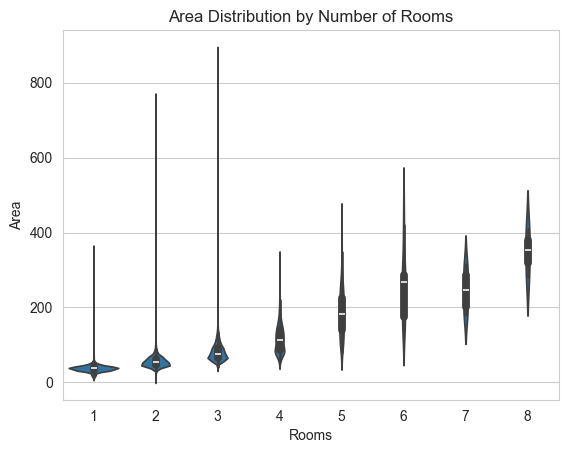

In [60]:
#9
plt.figure()
sns.violinplot(data=df, x='rooms', y='area_m2')
plt.title("Area Distribution by Number of Rooms")
plt.xlabel("Rooms")
plt.ylabel("Area")
plt.show()

# Caption: Larger apartments tend to have more rooms

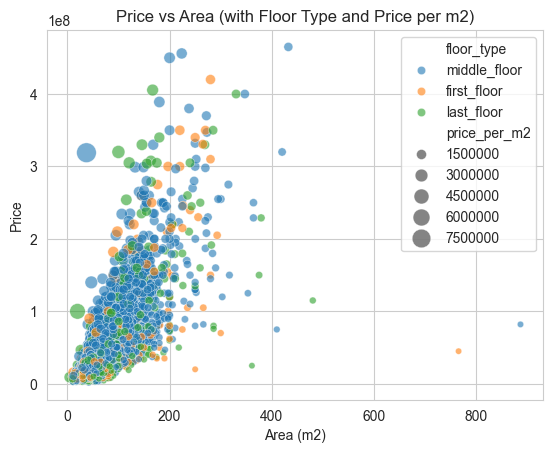

In [61]:
#10 Multi-variable scatterplot
plt.figure()

sns.scatterplot(
    data=df,
    x='area_m2',
    y='price',
    hue='floor_type',
    size='price_per_m2',
    sizes=(20, 200),
    alpha=0.6
)

plt.title("Price vs Area (with Floor Type and Price per m2)")
plt.xlabel("Area (m2)")
plt.ylabel("Price")

plt.show()

# Caption:
# Larger apartments generally have higher prices, and price per m2
# adds another layer of variation. Floor type slightly affects pricing.

In [62]:
#11 1st Interactive
import plotly.io as pio
import plotly.express as px
pio.renderers.default = "browser"


fig = px.scatter(df, x='area_m2', y='price', color='floor_type',
                 title="Interactive: Area vs Price")
fig.show()

In [63]:
#12 2nd Interactive
fig = px.box(df, x='price_category', y='price_per_m2',
             title="Interactive: Price per m2 by Category")
fig.show()

In [64]:
#13 3rd Interactive
fig = px.line(year_analysis, title="Interactive: Price Trend Over Time")
fig.show()

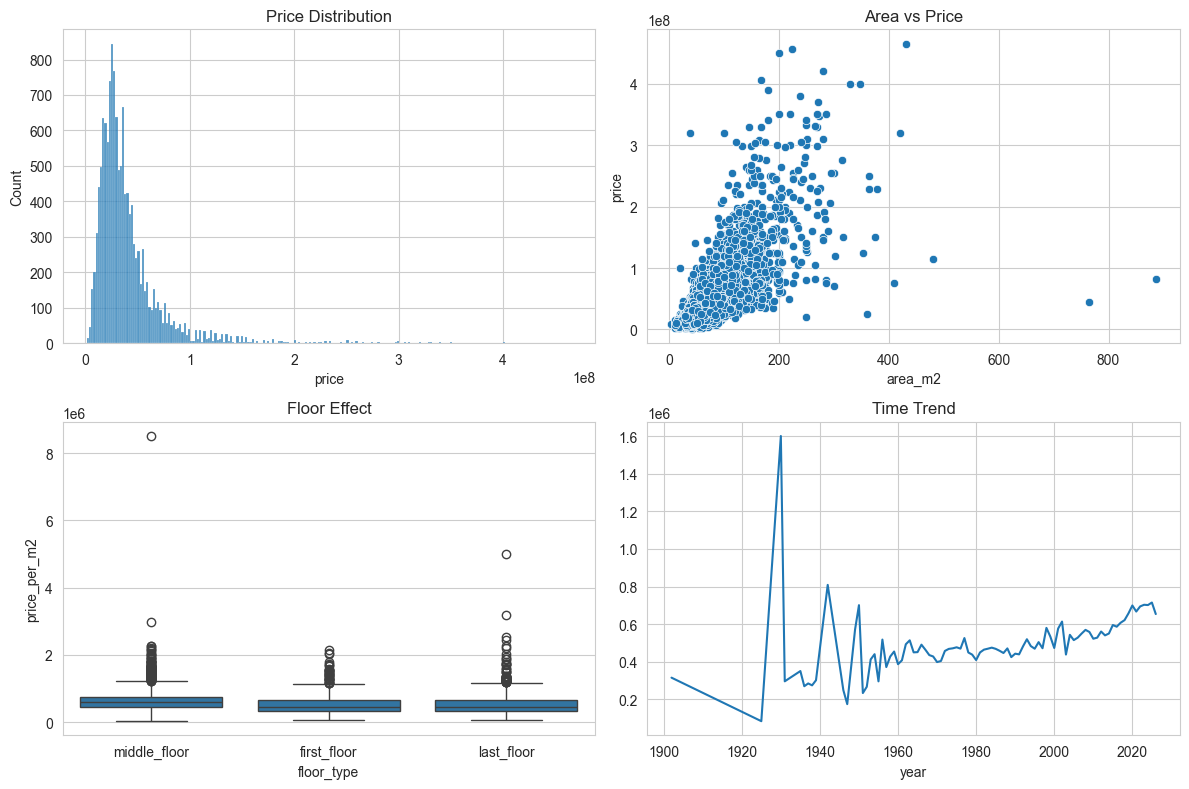

In [65]:
#14 Dashboard
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['price'], ax=axes[0,0])
axes[0,0].set_title("Price Distribution")

sns.scatterplot(data=df, x='area_m2', y='price', ax=axes[0,1])
axes[0,1].set_title("Area vs Price")

sns.boxplot(data=df, x='floor_type', y='price_per_m2', ax=axes[1,0])
axes[1,0].set_title("Floor Effect")

sns.lineplot(x=year_analysis.index, y=year_analysis.values, ax=axes[1,1])
axes[1,1].set_title("Time Trend")

plt.tight_layout()
plt.show()

**Machine learning models**

In this section, we build machine learning models to predict apartment prices.
We use:
- A baseline model: Linear Regression
- An advanced model: Random Forest

The goal is to evaluate how well we can predict apartment prices based on features such as area, number of rooms, floor, district, and building characteristics.

In [66]:
#Data preparation
from sklearn.model_selection import train_test_split
features = [
    'rooms', 'area_m2', 'floor', 'total_floors',
    'year', 'apartment_age'
]

# One-hot encoding for district
df_ml = pd.get_dummies(df, columns=['district'], drop_first=True)

X = df_ml[features + [col for col in df_ml.columns if 'district_' in col]]
y = df_ml['price']

# Remove missing values
data_ml = pd.concat([X, y], axis=1).dropna()

X = data_ml.drop('price', axis=1)
y = data_ml['price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (10570, 29)
Test size: (2643, 29)


In [67]:
'''Baseline Model: Linear Regression
It predicts apartment price as a linear combination of features such as area, number of rooms, floor, year, and district'''

'Baseline Model: Linear Regression\nIt predicts apartment price as a linear combination of features such as area, number of rooms, floor, year, and district'

In [68]:
#Linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("RMSE:", round(rmse_lr, 0))
print("R²:", round(r2_lr, 3))

Linear Regression Results
RMSE: 18409002.0
R²: 0.692


In [69]:
# Compare actual vs predicted (compares actual apartment prices with predicted values from the model)
comparison_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred_lr
})

print(comparison_df.head(10))

   Actual Price  Predicted Price
0      50000000         50159639
1     125000000        127297619
2      27000000         28187761
3      20000000         25524636
4      38000000         45126238
5      65000000         49278429
6      30500000         37857500
7      39000000         49539457
8      90500000         88858791
9      43000000         58882233


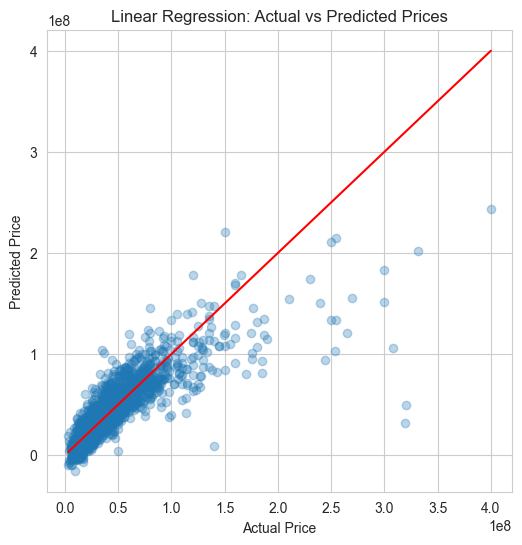

In [70]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.3)


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.show()

In [71]:
'''Advanced Model: Random Forest Regressor
It builds many decision trees and averages their predictions.
This helps capture nonlinear relationships between apartment characteristics and price'''

'Advanced Model: Random Forest Regressor\nIt builds many decision trees and averages their predictions.\nThis helps capture nonlinear relationships between apartment characteristics and price'

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("RMSE:", round(rmse_rf, 0))
print("R²:", round(r2_rf, 3))

Random Forest Results
RMSE: 17522634.0
R²: 0.721


In [73]:
comparison_rf = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred_rf
})

print(comparison_rf.head(10))

   Actual Price  Predicted Price
0      50000000         38433809
1     125000000        173010987
2      27000000         26095719
3      20000000         24417478
4      38000000         38740263
5      65000000         59858957
6      30500000         29319455
7      39000000         41417951
8      90500000         70989391
9      43000000         40760517


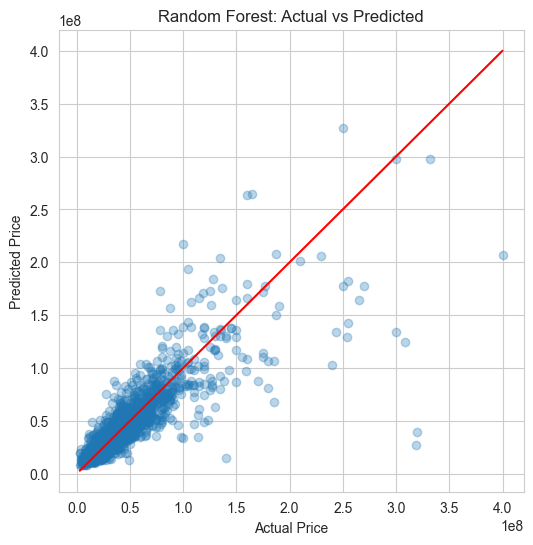

In [74]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [75]:
'''Model Comparison
We compare the Linear Regression model with the Random Forest model.
A better model should have lower RMSE and higher R²'''

'Model Comparison\nWe compare the Linear Regression model with the Random Forest model.\nA better model should have lower RMSE and higher R²'

In [76]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'R²': [r2_lr, r2_rf]
})

print(model_comparison)

               Model     RMSE  R²
0  Linear Regression 18409002   1
1      Random Forest 17522634   1


Cross-source comparison


In [77]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

def clean_number(text):
    return int(re.sub(r'\D', '', text)) if re.sub(r'\D', '', text) else None

def parse_korter_text(text):
    text = text.replace('\xa0', ' ').replace('‍', ' ')

    price_match = re.search(r'от\s*([\d\s]+)\s*₸', text)
    price = clean_number(price_match.group(1)) if price_match else None

    ppm_match = re.search(r'([\d\s]+)\s*₸\s*за\s*м', text)
    price_per_m2 = clean_number(ppm_match.group(1)) if ppm_match else None

    rooms_match = re.search(r'(\d+)\s*комнат', text)
    rooms = int(rooms_match.group(1)) if rooms_match else None

    area_match = re.search(r'(\d+[\.,]?\d*)\s*м\s*2', text)
    area_m2 = float(area_match.group(1).replace(',', '.')) if area_match else None

    return price, area_m2, rooms, price_per_m2


korter_data = []

for page in range(1, 20):
    url = f"https://korter.kz/продажа-квартир-алматы-дешевые?page={page}"

    response = requests.get(url, headers=headers, timeout=15)
    soup = BeautifulSoup(response.text, "html.parser")

    blocks = soup.find_all(["div", "article", "li"])

    for block in blocks:
        text = block.get_text(" ", strip=True)

        if "₸" not in text or "м" not in text:
            continue

        price, area_m2, rooms, price_per_m2 = parse_korter_text(text)

        if price and area_m2 and rooms:
            if price_per_m2 is None:
                price_per_m2 = price / area_m2

            if (
                1_000_000 <= price <= 500_000_000 and
                10 <= area_m2 <= 500 and
                50_000 <= price_per_m2 <= 3_000_000
            ):
                korter_data.append({
                    "source": "Korter.kz",
                    "price": price,
                    "area_m2": area_m2,
                    "rooms": rooms,
                    "price_per_m2": price_per_m2
                })

    print(f"Page {page} parsed")
    time.sleep(1)

korter_df = pd.DataFrame(korter_data).drop_duplicates()

print("Total records:", len(korter_df))
korter_df.head()

Page 1 parsed
Page 2 parsed
Page 3 parsed
Page 4 parsed
Page 5 parsed
Page 6 parsed
Page 7 parsed
Page 8 parsed
Page 9 parsed
Page 10 parsed
Page 11 parsed
Page 12 parsed
Page 13 parsed
Page 14 parsed
Page 15 parsed
Page 16 parsed
Page 17 parsed
Page 18 parsed
Page 19 parsed
Total records: 285


,source,price,area_m2,rooms,price_per_m2
0,Korter.kz,17787000,31,1,350000
8,Korter.kz,10780000,31,1,350000
10,Korter.kz,10815000,31,1,350000
12,Korter.kz,11264400,31,1,360000
14,Korter.kz,11325600,31,1,360000


In [78]:
krisha_astana = df[
    df['city'].str.contains('астана', case=False, na=False)
].copy()

krisha_astana = krisha_astana[['price', 'area_m2', 'rooms', 'price_per_m2']]
krisha_astana['source'] = 'Krisha.kz'

korter_compare = korter_df.copy()

comparison_df = pd.concat([krisha_astana, korter_compare], ignore_index=True)

summary = comparison_df.groupby('source').agg({
    'price': ['mean', 'median'],
    'area_m2': ['mean'],
    'price_per_m2': ['mean']
}).round(0)

print(summary)

             price          area_m2 price_per_m2
              mean   median    mean         mean
source                                          
Korter.kz 19573241 19826000      40       486660
Krisha.kz 44022006 35000000      67       650656
